# P04. Pipeline de limpeza de dados de processo

Uma função de limpeza reutilizável para dados de sensor de processo. O dado usado é o IndPenSim,
uma simulação de fermentação de penicilina em escala industrial. Ele vem limpo, então eu injeto
quatro defeitos comuns de propósito (outlier, sensor travado, unidade trocada, buraco no tempo),
escrevo uma função pra cada um, junto tudo num pipeline e no fim comparo com o gabarito.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Os dados

Uso um recorte do IndPenSim: as 3 primeiras bateladas e as 37 colunas de processo (sem os
2.200 canais de espectro Raman que existem no arquivo original). São 3.670 linhas, uma leitura
a cada 0,2 h.

O arquivo bruto tem um problema no cabeçalho: um dos nomes de coluna tem vírgulas soltas, o que
faz o leitor de CSV enxergar duas colunas a mais no cabeçalho do que nas linhas de dados, e
desalinha todos os rótulos. A preparação abaixo roda uma vez, ignora o cabeçalho e nomeia as
colunas na mão:

```python
nomes = ["tempo_h", "aeracao_L_h", "agitador_rpm", ...]   # 37 nomes, na ordem das colunas
bruto = pd.read_csv(caminho_do_arquivo_bruto, skiprows=1, header=None,
                    usecols=range(37), names=nomes)
amostra = bruto[bruto["batelada_id"].isin([1, 2, 3])].copy()
amostra.to_csv("../data/indpensim_processo.csv", index=False)
```

In [2]:
df = pd.read_csv("../data/indpensim_processo.csv")
df.shape

(3670, 37)

In [3]:
df.head()

,tempo_h,aeracao_L_h,agitador_rpm,acucar_L_h,acido_L_h,base_L_h,agua_resfriamento_L_h,agua_aquecimento_L_h,agua_injecao_L_h,pressao_topo_bar,...,biomassa_offline_g_L,cer_g_h,nh3_shots_kg,viscosidade_cp,falha_ref,controle_ref,pat_ref,batelada_ref,batelada_id,falha_flag
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,NaN,0.034045,0,NaN,0,0,1,1,1,0
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,NaN,0.038702,0,NaN,0,0,1,1,1,0
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,NaN,0.040240,0,NaN,0,0,1,1,1,0
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,NaN,0.041149,0,NaN,0,0,1,1,1,0
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,0.52808,0.041951,0,4.083,0,0,1,1,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3670 entries, 0 to 3669
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tempo_h                   3670 non-null   float64
 1   aeracao_L_h               3670 non-null   int64  
 2   agitador_rpm              3670 non-null   int64  
 3   acucar_L_h                3670 non-null   int64  
 4   acido_L_h                 3670 non-null   float64
 5   base_L_h                  3670 non-null   float64
 6   agua_resfriamento_L_h     3670 non-null   float64
 7   agua_aquecimento_L_h      3670 non-null   float64
 8   agua_injecao_L_h          3670 non-null   int64  
 9   pressao_topo_bar          3670 non-null   float64
 10  descarte_caldo_L_h        3670 non-null   int64  
 11  substrato_g_L             3670 non-null   float64
 12  oxigenio_dissolvido_mg_L  3670 non-null   float64
 13  penicilina_g_L            3670 non-null   float64
 14  volume_L           

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tempo_h,3670.0,123.574114,72.664708,2.000000e-01,61.250000,122.400000,183.600000,278.00000
aeracao_L_h,3670.0,65.193460,11.188962,3.000000e+01,60.000000,65.000000,75.000000,75.00000
agitador_rpm,3670.0,100.000000,0.000000,1.000000e+02,100.000000,100.000000,100.000000,100.00000
acucar_L_h,3670.0,76.791553,23.034189,8.000000e+00,80.000000,80.000000,90.000000,150.00000
acido_L_h,3670.0,0.069175,0.544548,0.000000e+00,0.000000,0.000000,0.000000,7.79880
base_L_h,3670.0,64.391152,40.957217,0.000000e+00,41.930750,60.594000,81.630250,225.00000
agua_resfriamento_L_h,3670.0,66.101222,80.354667,1.000000e-04,12.928500,38.558500,90.173250,817.92000
agua_aquecimento_L_h,3670.0,22.410619,50.927971,1.000000e-04,0.000100,0.015865,12.076250,543.67000
agua_injecao_L_h,3670.0,153.678474,153.078112,0.000000e+00,0.000000,100.000000,250.000000,500.00000
pressao_topo_bar,3670.0,0.941935,0.130094,6.000000e-01,0.900000,0.900000,1.000000,1.10000


pH e temperatura são variáveis controladas: ficam num intervalo estreito em torno de um alvo
(pH perto de 6,5, temperatura perto de 298 K). O oxigênio dissolvido varia mais, entre 6 e 16.
O agitador é constante em 100.

Cinco colunas (`paa_offline_g_L`, `nh3_offline_g_L`, `penicilina_offline_g_L`,
`biomassa_offline_g_L`, `viscosidade_cp`) têm só 66 valores nas 3.670 linhas. São medidas de
laboratório, tiradas de amostra manual de vez em quando, não sensor contínuo. Não são defeito,
é como esse tipo de medida funciona.

<Axes: xlabel='tempo_h'>

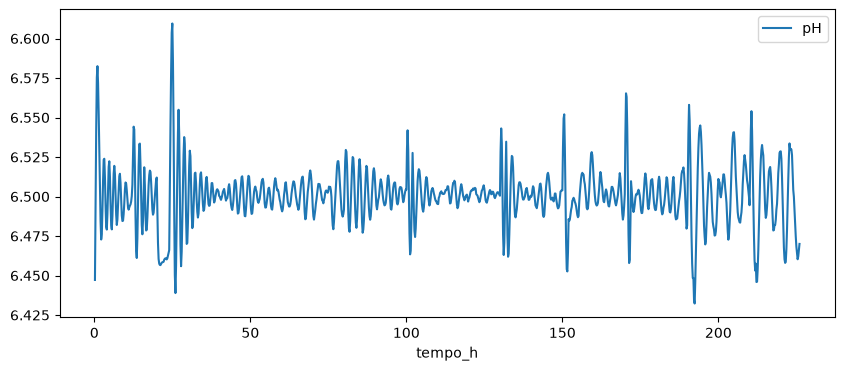

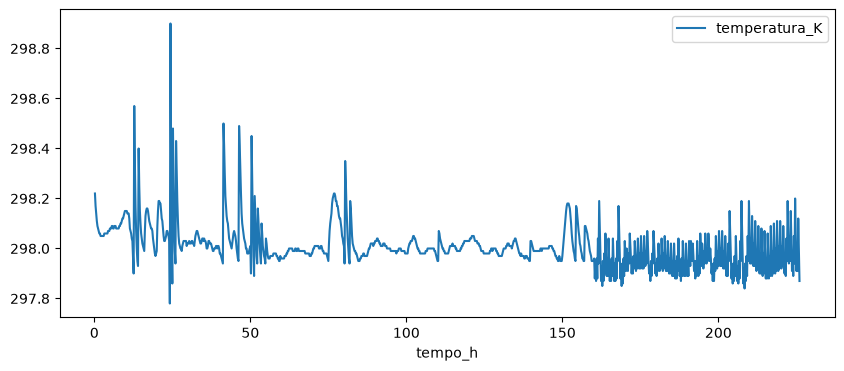

In [6]:
b1 = df[df["batelada_id"] == 1]
b1.plot(x="tempo_h", y="pH", figsize=(10, 4))
b1.plot(x="tempo_h", y="temperatura_K", figsize=(10, 4))

## Injetando os defeitos de propósito

O IndPenSim é limpo. Pra medir a limpeza depois, injeto os quatro defeitos com posição e valor
conhecidos. O `df` original fica intocado como gabarito, e a versão suja vai pra `sujo`.

In [7]:
# daqui pra frente o dado vira "sujo" de proposito. o df limpo continua intacto, e o gabarito.
sujo = df.copy()
rng = np.random.default_rng(42)   # semente fixa: a sujeira sai igual toda vez

# defeito 1: outliers no pH, 5 pontos espalhados na batelada 1
linhas_ph = [120, 305, 511, 780, 1010]
sujo.loc[linhas_ph, "pH"] = [11.5, 2.0, 10.8, -3.0, 13.5]

# defeito 2: sensor de oxigenio travado no ultimo valor, ~12 h da batelada 2
sujo.loc[1500:1560, "oxigenio_dissolvido_mg_L"] = sujo.loc[1499, "oxigenio_dissolvido_mg_L"]

# defeito 3: trecho da batelada 3 gravado em Celsius em vez de Kelvin
sujo.loc[2800:3000, "temperatura_K"] = sujo.loc[2800:3000, "temperatura_K"] - 273.15

# defeito 4: 25 leituras somem da batelada 3, criando buracos no tempo
linhas_removidas = sorted(int(x) for x in rng.choice(range(2280, 2800), size=25, replace=False))
sujo = sujo.drop(index=linhas_removidas)

sujo.to_csv("../data/indpensim_sujo.csv", index=False)
sujo.shape

(3645, 37)

## Limpeza

Uma função por defeito. Cada uma recebe um DataFrame e devolve outro corrigido, sem alterar o
que entrou.

### Defeito 1: outlier de sensor (pH)

No dado limpo o pH fica entre 6,3 e 6,7. Um processo real escapa um pouco disso, mas nunca vai
a pH 2 ou 11. Então marco como defeito tudo fora de uma faixa física larga (5 a 8), troco por
`NaN` e preencho com interpolação linear, que é razoável porque o buraco é de um ponto só.

In [8]:
def limpa_outliers_ph(df):
    df = df.copy()

    fora = (df['pH'] < 5) | (df['pH'] > 8)
    df.loc[fora, 'pH'] = np.nan

    df['pH'] = df['pH'].interpolate()

    return df

In [9]:
teste = limpa_outliers_ph(sujo)
pd.DataFrame({"limpo": teste.loc[linhas_ph, "pH"], "real": df.loc[linhas_ph, "pH"]})

,limpo,real
120,6.50515,6.5061
305,6.50650,6.5086
511,6.49410,6.4914
780,6.51320,6.5142
1010,6.50585,6.5051


### Defeito 2: sensor travado (oxigênio dissolvido)

Sensor travado repete o mesmo valor por muitas leituras seguidas. O acaso também repete valor,
mas só por 2 ou 3 leituras. Então meço o comprimento de cada corrida de valores idênticos:
`s != s.shift()` marca onde o valor muda, `.cumsum()` numera os trechos planos, e
`groupby(...).transform('size')` diz, pra cada linha, o tamanho do trecho dela. Corrida acima de
20 é travamento.

In [10]:
def limpa_sensor_travado(df, coluna, limite=20):
    df = df.copy()

    s = df[coluna]
    mudou = s != s.shift()
    bloco = mudou.cumsum()
    tamanho = s.groupby(bloco).transform('size')

    travado = tamanho > limite
    df.loc[travado, coluna] = np.nan
    df[coluna] = df[coluna].interpolate()

    return df

In [11]:
teste2 = limpa_sensor_travado(sujo, "oxigenio_dissolvido_mg_L")
print("nunique no trecho travado, antes:", sujo.loc[1500:1560, "oxigenio_dissolvido_mg_L"].nunique())
print("nunique no trecho travado, depois:", teste2.loc[1500:1560, "oxigenio_dissolvido_mg_L"].nunique())

nunique no trecho travado, antes: 1
nunique no trecho travado, depois: 61


### Defeito 3: unidade trocada (temperatura)

Um trecho da temperatura foi gravado em Celsius em vez de Kelvin, então marca ~25 onde devia
marcar ~298. Como a relação entre as unidades é fixa, dá pra desfazer exato: onde o valor é
baixo demais pra ser Kelvin de fermentador (abaixo de 200), somo 273,15 de volta. Diferente dos
outros dois, aqui não jogo nada fora.

In [12]:
def limpa_unidade_temp(df):
    df = df.copy()

    em_celsius = df['temperatura_K'] < 200
    df.loc[em_celsius, 'temperatura_K'] = df.loc[em_celsius, 'temperatura_K'] + 273.15

    return df

In [13]:
teste3 = limpa_unidade_temp(sujo)
print("linhas em Celsius, antes:", (sujo["temperatura_K"] < 200).sum())
print("linhas em Celsius, depois:", (teste3["temperatura_K"] < 200).sum())
teste3["temperatura_K"].describe()

linhas em Celsius, antes: 201
linhas em Celsius, depois: 0


count    3645.000000
mean      298.013218
std         0.129778
min       297.470000
25%       297.950000
50%       297.990000
75%       298.040000
max       299.870000
Name: temperatura_K, dtype: float64

### Defeito 4: buraco no tempo

25 leituras foram removidas da batelada 3, então a diferença entre tempos consecutivos, que
devia ser sempre 0,2 h, pula pra 0,4 ou 0,6 em vários pontos.

In [14]:
b3 = sujo[sujo["batelada_id"] == 3]
passo = b3["tempo_h"].diff()
passo[passo > 0.2001]   # os saltos, cada um e uma ou duas leituras que faltam

2325    0.6
2328    0.4
2346    0.4
2375    0.4
2382    0.4
2472    0.4
2497    0.4
2500    0.4
2512    0.4
2539    0.4
2543    0.4
2547    0.4
2606    0.4
2631    0.4
2646    0.4
2654    0.4
2665    0.4
2668    0.4
2682    0.4
2687    0.4
2712    0.6
2761    0.4
2775    0.4
Name: tempo_h, dtype: float64

A correção: pra cada batelada, monto a grade de tempo completa de 0,2 em 0,2, do primeiro ao
último instante, e uso `reindex` pra forçar a batelada a ter exatamente esses instantes. Os que
faltavam entram como linha vazia, e a interpolação preenche. O `.round(1)` no tempo é pra o
`reindex` casar os números apesar do erro de ponto flutuante.

In [15]:
def limpa_buracos_tempo(df, passo=0.2):
    df = df.copy()
    df['tempo_h'] = df['tempo_h'].round(1)   # tira o lixo de ponto flutuante do tempo

    pedacos = []
    for bid in df['batelada_id'].unique():
        b = df[df['batelada_id'] == bid].set_index('tempo_h')

        grade = np.round(np.arange(b.index.min(), b.index.max() + passo / 2, passo), 1)

        b = b.reindex(grade)      # cria linha vazia nos instantes que faltavam
        b = b.interpolate()       # preenche essas linhas
        b['batelada_id'] = bid

        pedacos.append(b.reset_index())

    return pd.concat(pedacos, ignore_index=True)

In [16]:
teste4 = limpa_buracos_tempo(sujo)
b3_depois = teste4[teste4["batelada_id"] == 3]
print(sujo.shape, "->", teste4.shape)
print("saltos != 0.2 na batelada 3, depois:", int((b3_depois["tempo_h"].diff().round(4) > 0.2001).sum()))

(3645, 37) -> (3670, 37)
saltos != 0.2 na batelada 3, depois: 0


## O pipeline

As quatro funções na ordem certa. Os buracos ficam por último, senão a reconstrução da grade
interpola por cima da sujeira que ainda não foi tratada.

In [17]:
def limpa(df):
    df = limpa_outliers_ph(df)
    df = limpa_sensor_travado(df, "oxigenio_dissolvido_mg_L")
    df = limpa_unidade_temp(df)
    df = limpa_buracos_tempo(df)
    return df

## Validação

Rodo `limpa()` no `sujo` e comparo com o gabarito leitura a leitura, casando pelas chaves
batelada e tempo.

In [18]:
resultado = limpa(sujo)
print(sujo.shape, "->", resultado.shape)

gabarito = df.copy()
gabarito["tempo_h"] = gabarito["tempo_h"].round(1)

comp = resultado.merge(gabarito, on=["batelada_id", "tempo_h"], suffixes=("_limpo", "_real"))

for col in ["pH", "oxigenio_dissolvido_mg_L", "temperatura_K"]:
    erro = (comp[col + "_limpo"] - comp[col + "_real"]).abs()
    print(f"{col}: erro medio {erro.mean():.5f}, erro max {erro.max():.4f}")

(3645, 37) -> (3670, 37)
pH: erro medio 0.00001, erro max 0.0050
oxigenio_dissolvido_mg_L: erro medio 0.00535, erro max 0.7986
temperatura_K: erro medio 0.00014, erro max 0.2250


## Antes e depois

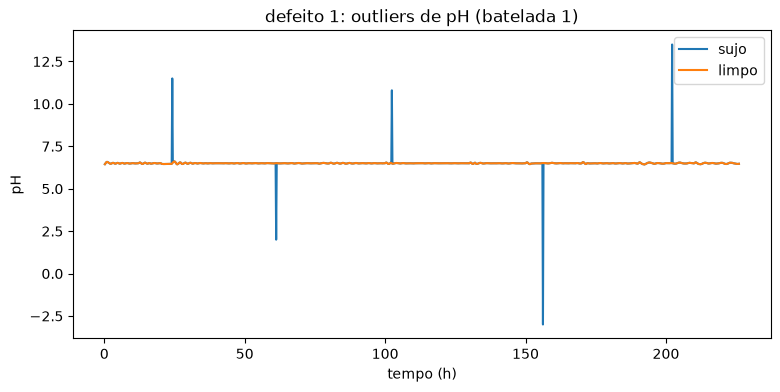

In [19]:
# defeito 1: outliers de pH, batelada 1 inteira
s = sujo[sujo["batelada_id"] == 1]
r = resultado[resultado["batelada_id"] == 1]

plt.figure(figsize=(9, 4))
plt.plot(s["tempo_h"], s["pH"], label="sujo")
plt.plot(r["tempo_h"], r["pH"], label="limpo")
plt.xlabel("tempo (h)"); plt.ylabel("pH"); plt.legend()
plt.title("defeito 1: outliers de pH (batelada 1)")
plt.savefig("../images/defeito1_ph.png", dpi=110, bbox_inches="tight")

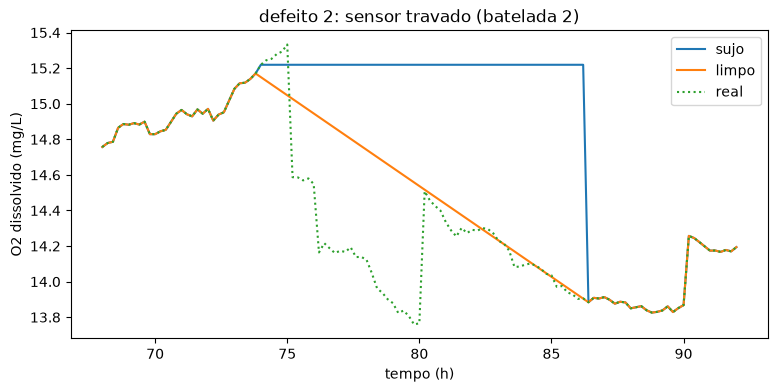

In [20]:
# defeito 2: sensor de O2 travado, batelada 2
s = sujo[(sujo["batelada_id"] == 2) & (sujo["tempo_h"].between(68, 92))]
r = resultado[(resultado["batelada_id"] == 2) & (resultado["tempo_h"].between(68, 92))]
g = gabarito[(gabarito["batelada_id"] == 2) & (gabarito["tempo_h"].between(68, 92))]

plt.figure(figsize=(9, 4))
plt.plot(s["tempo_h"], s["oxigenio_dissolvido_mg_L"], label="sujo")
plt.plot(r["tempo_h"], r["oxigenio_dissolvido_mg_L"], label="limpo")
plt.plot(g["tempo_h"], g["oxigenio_dissolvido_mg_L"], ":", label="real")
plt.xlabel("tempo (h)"); plt.ylabel("O2 dissolvido (mg/L)"); plt.legend()
plt.title("defeito 2: sensor travado (batelada 2)")
plt.savefig("../images/defeito2_oxigenio.png", dpi=110, bbox_inches="tight")

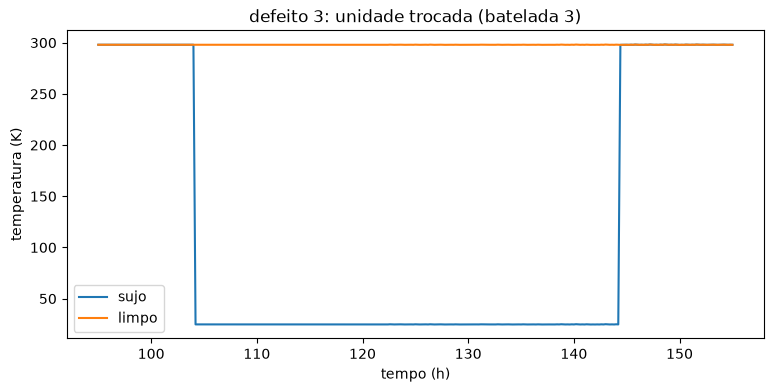

In [21]:
# defeito 3: temperatura em Celsius num trecho, batelada 3
s = sujo[(sujo["batelada_id"] == 3) & (sujo["tempo_h"].between(95, 155))]
r = resultado[(resultado["batelada_id"] == 3) & (resultado["tempo_h"].between(95, 155))]

plt.figure(figsize=(9, 4))
plt.plot(s["tempo_h"], s["temperatura_K"], label="sujo")
plt.plot(r["tempo_h"], r["temperatura_K"], label="limpo")
plt.xlabel("tempo (h)"); plt.ylabel("temperatura (K)"); plt.legend()
plt.title("defeito 3: unidade trocada (batelada 3)")
plt.savefig("../images/defeito3_temperatura.png", dpi=110, bbox_inches="tight")

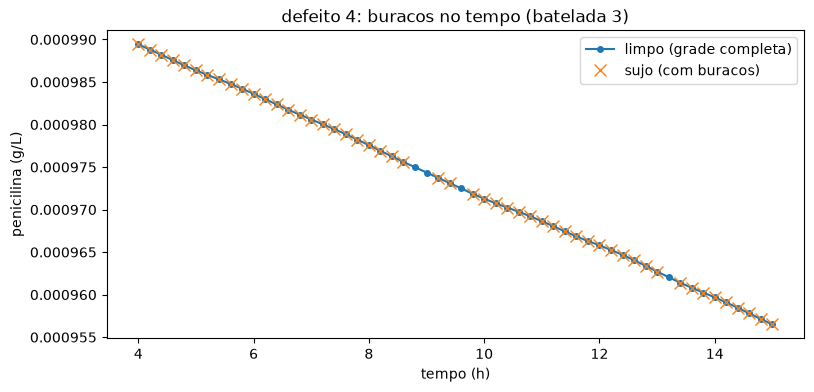

In [22]:
# defeito 4: buracos no tempo, batelada 3, janela curta com marcadores
s = sujo[(sujo["batelada_id"] == 3) & (sujo["tempo_h"].between(4, 15))]
r = resultado[(resultado["batelada_id"] == 3) & (resultado["tempo_h"].between(4, 15))]

plt.figure(figsize=(9, 4))
plt.plot(r["tempo_h"], r["penicilina_g_L"], "-o", ms=4, label="limpo (grade completa)")
plt.plot(s["tempo_h"], s["penicilina_g_L"], "x", ms=8, label="sujo (com buracos)")
plt.xlabel("tempo (h)"); plt.ylabel("penicilina (g/L)"); plt.legend()
plt.title("defeito 4: buracos no tempo (batelada 3)")
plt.savefig("../images/defeito4_buracos.png", dpi=110, bbox_inches="tight")

## Limitações

Interpolar serve bem pra buraco curto e mal pra buraco longo. O trecho de oxigênio travado tem
62 leituras (~12 h), e a interpolação troca a linha reta travada por uma rampa reta, que
também não é o que aconteceu. Quase todo o erro máximo de 0,8 mg/L mora ali. Pra esse caso,
marcar o período como não confiável seria mais honesto.

Reconstruir as 25 linhas que sumiram é uma escolha, não um passo neutro. Dependendo do uso, o
certo pode ser deixar o buraco documentado em vez de inventar leitura.

As interpolações rodam na coluna inteira. Só quebraria se um defeito caísse na borda de uma
batelada, o que não acontece nesse recorte. Pra generalizar, cada função pediria um
`groupby("batelada_id")` em volta.